\# Transformers: An Application-Oriented Guide

## 1. Introduction to Transformers

Transformers are a groundbreaking neural network architecture introduced in the paper "Attention Is All You Need" (Vaswani et al., 2017). They have revolutionized the field of Natural Language Processing (NLP) and are now widely used for tasks like text generation, translation, summarization, and more.

The core idea behind Transformers is the **attention mechanism**, which allows the model to weigh the importance of different parts of the input sequence when processing each element. Unlike traditional recurrent neural networks (RNNs), Transformers process sequences in parallel, making them much faster and more efficient for long sequences.

### Key Components:
*   **Self-Attention**: Allows the model to look at other words in the input sequence to get a better understanding of the context of each word.
*   **Multi-Head Attention**: Runs the attention mechanism multiple times in parallel to capture different types of relationships.
*   **Feed-Forward Networks**: Standard neural network layers applied independently to each position.
*   **Positional Encodings**: Since Transformers don't have inherent sequential processing, positional encodings are added to the input embeddings to provide information about the relative or absolute position of tokens in the sequence.
*   **Encoder-Decoder Structure**: The original Transformer consists of an encoder stack and a decoder stack, each with multiple identical layers.
    *   **Encoder**: Processes the input sequence and transforms it into a rich representation.
    *   **Decoder**: Takes the encoder's output and generates the output sequence, often attending to both the encoder's output and its own previously generated tokens.

## 2. Setting Up Hugging Face Transformers

The Hugging Face `transformers` library provides thousands of pre-trained models to perform tasks on texts, images, audio, and more. It offers a high-level API that makes it easy to download, fine-tune, and use state-of-the-art models.

First, let's install the necessary library.

In [ ]:
# Install the Hugging Face Transformers library
!pip install transformers sentence-transformers -q

## 3. Quick Start with `pipeline()`

The `pipeline` function is the easiest way to use pre-trained models for inference. It abstracts away the complexities of tokenization, model loading, and output post-processing — you simply choose a task name, and Hugging Face loads a sensible default model for it.


### 3.1 Exploring Available Pipeline Tasks

Before diving into applications, let's look at what tasks `pipeline()` supports out of the box.


In [1]:
# ============================================================================
# SUPPORTED_TASKS
# ----------------------------------------------------------------------------
# - A dictionary containing the core built-in pipeline tasks supported by
#   Hugging Face Transformers.
# - Stores metadata such as:
#     * Pipeline implementation class
#     * PyTorch model class
#     * TensorFlow model class
#     * Default model mappings
# - Primarily used internally by the Transformers library.
# - Usually contains only the canonical/internal task names.
# - Example:
#     sentiment-analysis -> text-classification
#     ner                -> token-classification
#   Therefore aliases like "sentiment-analysis" and "ner" may not appear here.
# ============================================================================

from transformers.pipelines import SUPPORTED_TASKS

print(f"Total tasks: {len(SUPPORTED_TASKS)}")
print("*"*70)
for task in SUPPORTED_TASKS:
    print(task)
print("*"*70)

Total tasks: 24
**********************************************************************
audio-classification
automatic-speech-recognition
text-to-audio
feature-extraction
text-classification
token-classification
table-question-answering
document-question-answering
fill-mask
text-generation
zero-shot-classification
zero-shot-image-classification
zero-shot-audio-classification
image-classification
image-feature-extraction
image-segmentation
image-text-to-text
object-detection
zero-shot-object-detection
depth-estimation
video-classification
mask-generation
keypoint-matching
any-to-any
**********************************************************************


In [2]:
# ============================================================================
# PIPELINE_REGISTRY
# ----------------------------------------------------------------------------
# - A registry object that manages all available pipelines.
# - Used by the pipeline() API to resolve and instantiate pipelines.
# - Includes:
#     * Built-in tasks
#     * User-friendly aliases
#     * Custom registered pipelines
# - More dynamic and extensible than SUPPORTED_TASKS.
# - Often shows aliases such as:
#     sentiment-analysis
#     ner
#     question-answering
# - Supports custom pipeline registration through:
#     PIPELINE_REGISTRY.register_pipeline(...)
# ============================================================================
from transformers.pipelines import PIPELINE_REGISTRY

for task in sorted(PIPELINE_REGISTRY.get_supported_tasks()):
    print(task)

any-to-any
audio-classification
automatic-speech-recognition
depth-estimation
document-question-answering
feature-extraction
fill-mask
image-classification
image-feature-extraction
image-segmentation
image-text-to-text
keypoint-matching
mask-generation
ner
object-detection
sentiment-analysis
table-question-answering
text-classification
text-generation
text-to-audio
text-to-speech
token-classification
video-classification
zero-shot-audio-classification
zero-shot-classification
zero-shot-image-classification
zero-shot-object-detection


## 4. Three Transformer Architectures

Every Transformer application in this notebook is built on one of three architectural patterns. Knowing which pattern a task needs is the single most useful mental model for working with Transformers.


### 4.1 Encoder-Only, Decoder-Only, and Encoder-Decoder Models

Transformers can be broadly categorized into three types based on their architecture:

*   **Encoder-Only Models** (e.g., BERT, RoBERTa): These models are designed to understand and encode the input text. They are excellent for tasks that require a deep understanding of the input, such as sentiment analysis, classification, and named entity recognition.
    *   **Analogy**: Think of them as expert readers who can understand complex texts and summarize their main points, but they don't generate new content.

*   **Decoder-Only Models** (e.g., GPT, LLaMA): These models are designed for text generation. They take a prompt and predict the next token in a sequence, effectively generating new text. They are used for tasks like creative writing, chatbots, and code generation.
    *   **Analogy**: These are like creative writers who can continue a story or generate new ideas based on a given starting point.

*   **Encoder-Decoder Models** (e.g., T5, BART): These models combine both an encoder and a decoder. The encoder processes the input, and the decoder generates an output based on the encoder's representation. They are ideal for sequence-to-sequence tasks like machine translation, summarization, and question answering where an output sequence is generated from an input sequence.
    *   **Analogy**: Imagine a translator who first understands the original language (encoder) and then translates it into another language (decoder).

### 4.2 Choosing the Right Architecture for Your Task

Choosing the right Transformer model depends heavily on your specific task. Here's a general guide:

*   **Classification (e.g., sentiment analysis, spam detection)**:
    *   **Best Fit**: Encoder-only models (e.g., BERT, RoBERTa, DistilBERT).
    *   **Why**: They excel at understanding the full context of a sentence to make a prediction about it.
    *   **Hugging Face Pipeline**: `pipeline("sentiment-analysis")`, `pipeline("zero-shot-classification")`

*   **Similarity (e.g., semantic search, paraphrasing, clustering)**:
    *   **Best Fit**: Sentence Transformers (specialized encoder models like `all-MiniLM-L6-v2`).
    *   **Why**: They are specifically trained to produce semantically rich sentence embeddings.
    *   **Hugging Face Library**: `SentenceTransformer` from `sentence_transformers`

*   **Generation (e.g., creative writing, chatbot responses, code generation)**:
    *   **Best Fit**: Decoder-only models (e.g., GPT-2, GPT-Neo, LLaMA-based models).
    *   **Why**: They are designed to predict the next word in a sequence, generating coherent and contextually relevant text.
    *   **Hugging Face Pipeline**: `pipeline("text-generation")`

*   **Summarization (e.g., abstractive, extractive)**:
    *   **Best Fit**: Encoder-decoder models (e.g., BART, T5, Pegasus).
    *   **Why**: Similar to translation, an input sequence (long text) is mapped to an output sequence (summary).
    *   **Hugging Face Pipeline**: `pipeline("summarization")`

*   **Question Answering (e.g., extractive QA, generative QA)**:
    *   **Best Fit**: Encoder-only for extractive (e.g., BERT, RoBERTa), Encoder-decoder for generative (e.g., T5).
    *   **Why**: Extractive models find the answer span in the context. Generative models generate an answer from scratch.
    *   **Hugging Face Pipeline**: `pipeline("question-answering")`

## 5. Encoder-Only Applications (Understanding Tasks)

Encoder-only models read the *entire* input at once (bidirectional context) and produce a rich representation of it. They don't generate new text — they understand, classify, and extract. Below are the most common encoder-only applications.


### 5.1 Text Classification (Sentiment Analysis)

Text classification involves assigning a label or category to a given text. Let's classify some movie reviews as positive or negative.


In [3]:
from transformers import pipeline

# Load a pre-trained sentiment analysis pipeline
classifier = pipeline("sentiment-analysis")

# Classify some texts
texts = [
    "This movie is absolutely fantastic! I loved every minute of it.",
    "The plot was convoluted and the acting was terrible.",
    "It's a decent film, nothing groundbreaking but enjoyable."
]

for text in texts:
    result = classifier(text)
    print(f"Text: {text}\nSentiment: {result[0]['label']}, Score: {result[0]['score']:.2f}\n")

[transformers] No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

Text: This movie is absolutely fantastic! I loved every minute of it.
Sentiment: POSITIVE, Score: 1.00

Text: The plot was convoluted and the acting was terrible.
Sentiment: NEGATIVE, Score: 1.00

Text: It's a decent film, nothing groundbreaking but enjoyable.
Sentiment: POSITIVE, Score: 1.00



In [4]:
print(classifier.model.name_or_path)

distilbert/distilbert-base-uncased-finetuned-sst-2-english


### 5.2 Text Tokenization

Tokenization is the process of breaking text into smaller units called **tokens**. These tokens are then converted into numerical **token IDs** that a language model can understand. Let's see how `AutoTokenizer` performs **tokenization, encoding, and decoding** on a given text.

In [5]:
from transformers import AutoTokenizer

# Load the tokenizer associated with a pre-trained model
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

texts = [
    "This movie is absolutely fantastic!",
    "The plot was convoluted and the acting was terrible.",
]

for text in texts:
    print("=" * 80)
    print(f"Original Text:\n{text}\n")

    # 1. Tokenization
    tokens = tokenizer.tokenize(text)
    print(f"1. Tokens:\n{tokens}\n")

    # 2. Encoding: Tokens → Token IDs
    token_ids = tokenizer.encode(text)
    print(f"2. Token IDs:\n{token_ids}\n")

    # 3. Decoding: Token IDs → Text
    decoded_text = tokenizer.decode(token_ids)
    print(f"3. Decoded Text:\n{decoded_text}\n")

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Original Text:
This movie is absolutely fantastic!

1. Tokens:
['this', 'movie', 'is', 'absolutely', 'fantastic', '!']

2. Token IDs:
[101, 2023, 3185, 2003, 7078, 10392, 999, 102]

3. Decoded Text:
[CLS] this movie is absolutely fantastic! [SEP]

Original Text:
The plot was convoluted and the acting was terrible.

1. Tokens:
['the', 'plot', 'was', 'con', '##vo', '##lu', '##ted', 'and', 'the', 'acting', 'was', 'terrible', '.']

2. Token IDs:
[101, 1996, 5436, 2001, 9530, 6767, 7630, 3064, 1998, 1996, 3772, 2001, 6659, 1012, 102]

3. Decoded Text:
[CLS] the plot was convoluted and the acting was terrible. [SEP]



### 5.3 Question Answering (Extractive)

Question Answering models can extract answers from a given context. Let's try to answer a question based on a provided text.


In [6]:
from transformers import AutoTokenizer, AutoModelForQuestionAnswering
import torch

model_name = "distilbert-base-cased-distilled-squad"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model     = AutoModelForQuestionAnswering.from_pretrained(model_name)

context  = "The Eiffel Tower is a wrought-iron lattice tower on the Champ de Mars in Paris, France..."
question = "Who designed the Eiffel Tower?"

inputs = tokenizer(question, context, return_tensors="pt")

with torch.no_grad():
    outputs = model(**inputs)

start = outputs.start_logits.argmax()
end   = outputs.end_logits.argmax() + 1
answer = tokenizer.convert_tokens_to_string(
    tokenizer.convert_ids_to_tokens(inputs["input_ids"][0][start:end])
)

print(f"Answer: {answer}")

config.json:   0%|          | 0.00/473 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/213k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/436k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  261MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/102 [00:00<?, ?it/s]

Answer: Champ de Mars in Paris, France.


### 5.4 Named Entity Recognition (NER)

Named Entity Recognition identifies and labels real-world entities in text — people, organizations, locations, and more.


In [7]:
# ══════════════════════════════════════════════════
# Named Entity Recognition (NER)
# Model: dslim/bert-base-NER
# Finds: PER (people), ORG (organizations), LOC (locations), MISC
# ══════════════════════════════════════════════════
ner = pipeline(
    "ner",
    model="dslim/bert-base-NER",
    aggregation_strategy="simple"   # merge sub-word tokens
)

texts = [
    "Sundar Pichai is the CEO of Google, which is headquartered in Mountain View, California.",
    "The FIFA World Cup 2026 will be held in the United States, Canada, and Mexico.",
    "Elon Musk founded SpaceX in 2002 and acquired Twitter, renaming it to X.",
]

entity_icons = {"PER": "👤", "ORG": "🏢", "LOC": "📍", "MISC": "🔖"}

for text in texts:
    entities = ner(text)
    print(f"\n📝 {text}")
    print(f"  {'Type':6s}  {'Entity':25s}  Confidence")
    print(f"  {'─'*6}  {'─'*25}  {'─'*10}")
    for e in entities:
        icon = entity_icons.get(e['entity_group'], '🔖')
        print(f"  {icon} {e['entity_group']:4s}  {e['word']:25s}  {e['score']:.2%}")

config.json:   0%|          | 0.00/829 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  433MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForTokenClassification LOAD REPORT from: dslim/bert-base-NER
Key                      | Status     |  | 
-------------------------+------------+--+-
bert.pooler.dense.weight | UNEXPECTED |  | 
bert.pooler.dense.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/59.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/213k [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]


📝 Sundar Pichai is the CEO of Google, which is headquartered in Mountain View, California.
  Type    Entity                     Confidence
  ──────  ─────────────────────────  ──────────
  👤 PER   Sundar Pichai              99.19%
  🏢 ORG   Google                     99.89%
  📍 LOC   Mountain View              99.77%
  📍 LOC   California                 99.92%

📝 The FIFA World Cup 2026 will be held in the United States, Canada, and Mexico.
  Type    Entity                     Confidence
  ──────  ─────────────────────────  ──────────
  🔖 MISC  FIFA World Cup 2026        91.35%
  📍 LOC   United States              99.95%
  📍 LOC   Canada                     99.98%
  📍 LOC   Mexico                     99.98%

📝 Elon Musk founded SpaceX in 2002 and acquired Twitter, renaming it to X.
  Type    Entity                     Confidence
  ──────  ─────────────────────────  ──────────
  🏢 ORG   Elon                       88.68%
  👤 PER   Mu                         56.98%
  🏢 ORG   ##sk        

### 5.5 Part-of-Speech Tagging (POS)

Part-of-Speech tagging assigns a grammatical category (noun, verb, adjective, etc.) to each token in a sentence. It's a sibling task to NER — both are **token classification** problems where every token gets its own label, rather than the whole sequence getting one label.

**Model type used:** Encoder-Only (e.g., `vblagoje/bert-english-uncased-finetuned-pos`)

**Real-world uses:** Grammar checkers, syntactic parsing, information extraction pipelines, linguistic research.


In [8]:
# ══════════════════════════════════════════════════
# Part-of-Speech (POS) Tagging
# Model: vblagoje/bert-english-uncased-finetuned-pos
# Assigns a grammatical tag (NOUN, VERB, ADJ, etc.) to every token
# ══════════════════════════════════════════════════
pos_tagger = pipeline(
    "token-classification",
    model="vblagoje/bert-english-uncased-finetuned-pos",
    aggregation_strategy="simple"
)

texts = [
    "The quick brown fox jumps over the lazy dog.",
    "Transformers have revolutionised natural language processing.",
]

for text in texts:
    tags = pos_tagger(text)
    print(f"\n📝 {text}")
    print(f"  {'Tag':8s}  {'Word':20s}  Confidence")
    print(f"  {'─'*8}  {'─'*20}  {'─'*10}")
    for t in tags:
        print(f"  {t['entity_group']:8s}  {t['word']:20s}  {t['score']:.2%}")


config.json:   0%|          | 0.00/1.06k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  438MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForTokenClassification LOAD REPORT from: vblagoje/bert-english-uncased-finetuned-pos
Key                      | Status     |  | 
-------------------------+------------+--+-
bert.pooler.dense.weight | UNEXPECTED |  | 
bert.pooler.dense.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]


📝 The quick brown fox jumps over the lazy dog.
  Tag       Word                  Confidence
  ────────  ────────────────────  ──────────
  DET       the                   99.94%
  ADJ       quick brown           96.97%
  NOUN      fox                   99.70%
  VERB      jumps                 99.94%
  ADP       over                  99.93%
  DET       the                   99.95%
  ADJ       lazy                  99.79%
  NOUN      dog                   99.89%
  PUNCT     .                     99.97%

📝 Transformers have revolutionised natural language processing.
  Tag       Word                  Confidence
  ────────  ────────────────────  ──────────
  NOUN      transformers          99.46%
  AUX       have                  99.79%
  VERB      revolutionised        99.93%
  ADJ       natural               99.76%
  NOUN      language processing   99.71%
  PUNCT     .                     99.97%


### 5.6 Sentence-Pair Classification (Paraphrase Detection)

Some classification tasks take **two** sentences as input rather than one — the model reads both together and predicts a relationship between them. A classic example is duplicate-question detection: given two questions, are they asking the same thing?

**Model type used:** Encoder-Only (e.g., `textattack/bert-base-uncased-QQP`, fine-tuned on the Quora Question Pairs dataset)

**Real-world uses:** Deduplicating forum/support questions, detecting plagiarism, paraphrase mining.


In [9]:
# ══════════════════════════════════════════════════
# Sentence-Pair Classification — Paraphrase / Duplicate Detection
# Model: textattack/bert-base-uncased-QQP (Quora Question Pairs)
# Uses tokenizer + model directly since this task needs two sentences as input
# ══════════════════════════════════════════════════
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch

model_name = "textattack/bert-base-uncased-QQP"
pair_tokenizer = AutoTokenizer.from_pretrained(model_name)
pair_model = AutoModelForSequenceClassification.from_pretrained(model_name)

# QQP labels: 0 = not duplicate, 1 = duplicate
labels = ["Not Duplicate", "Duplicate"]

question_pairs = [
    ("How do I learn Python?", "What is the best way to learn Python programming?"),
    ("How do I learn Python?", "What is the capital of France?"),
    ("Is the sky blue?", "Why does the sky appear blue?"),
]

for q1, q2 in question_pairs:
    inputs = pair_tokenizer(q1, q2, return_tensors="pt", truncation=True)
    with torch.no_grad():
        outputs = pair_model(**inputs)
    probs = torch.softmax(outputs.logits, dim=-1)[0]
    pred = probs.argmax().item()
    print(f"Q1: {q1}")
    print(f"Q2: {q2}")
    print(f"→ {labels[pred]}  (confidence: {probs[pred]:.2%})\n")


config.json:   0%|          | 0.00/475 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  438MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Q1: How do I learn Python?
Q2: What is the best way to learn Python programming?
→ Duplicate  (confidence: 61.80%)

Q1: How do I learn Python?
Q2: What is the capital of France?
→ Not Duplicate  (confidence: 99.99%)

Q1: Is the sky blue?
Q2: Why does the sky appear blue?
→ Not Duplicate  (confidence: 91.54%)



### 5.7 Fill-Mask (Masked Language Modelling)

Fill-mask is the original pre-training task for encoder-only models like BERT.
A word in the sentence is replaced with a special `[MASK]` token and the model predicts what word belongs there.

**Model type used:** Encoder-Only (e.g., `bert-base-uncased`, `roberta-base`)

Unlike text generation (which predicts the *next* token), fill-mask predicts a *missing* token using **bidirectional context** — it looks at words both before and after the mask. This is why encoder-only models are so powerful for understanding tasks.

**Real-world uses:**
- Auto-complete and spell-correction
- Understanding how language models "think" about word choices
- Probing model biases
- Data augmentation (replacing words with plausible alternatives)


In [10]:
from transformers import pipeline

# ── Load the fill-mask pipeline ───────────────────────────────────────────────
# bert-base-uncased uses [MASK] as the mask token.
# roberta-base uses <mask> — the pipeline handles this automatically.
fill_masker = pipeline("fill-mask", model="bert-base-uncased")

# ── Example 1: Factual knowledge ─────────────────────────────────────────────
masked_sentence_1 = "The capital of France is [MASK]."

print("Sentence:", masked_sentence_1)
print()
results_1 = fill_masker(masked_sentence_1)

print(f"{'Token':15s}  {'Score':>7s}")
print("-" * 26)
for r in results_1:
    bar = "█" * int(r["score"] * 40)
    print(f"{r['token_str']:15s}  {r['score']:>7.4f}  {bar}")


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  440MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

[transformers] BertForMaskedLM LOAD REPORT from: bert-base-uncased
Key                         | Status     |  | 
----------------------------+------------+--+-
cls.seq_relationship.weight | UNEXPECTED |  | 
cls.seq_relationship.bias   | UNEXPECTED |  | 
bert.pooler.dense.weight    | UNEXPECTED |  | 
bert.pooler.dense.bias      | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Sentence: The capital of France is [MASK].

Token              Score
--------------------------
paris             0.4168  ████████████████
lille             0.0714  ██
lyon              0.0634  ██
marseille         0.0444  █
tours             0.0303  █


In [11]:
# ── Example 2: Contextual word choice ────────────────────────────────────────
masked_sentences = [
    "The doctor examined the [MASK] carefully before making a diagnosis.",
    "She opened the [MASK] and started reading the first chapter.",
    "The [MASK] scored a goal in the final minute of the match.",
]

for sentence in masked_sentences:
    print(f"Sentence : {sentence}")
    results = fill_masker(sentence, top_k=3)  # top_k: return top 3 predictions
    for r in results:
        print(f"  [{r['token_str']:12s}]  score={r['score']:.4f}  →  {r['sequence']}")
    print()


Sentence : The doctor examined the [MASK] carefully before making a diagnosis.
  [patient     ]  score=0.1512  →  the doctor examined the patient carefully before making a diagnosis.
  [wound       ]  score=0.1138  →  the doctor examined the wound carefully before making a diagnosis.
  [body        ]  score=0.0500  →  the doctor examined the body carefully before making a diagnosis.

Sentence : She opened the [MASK] and started reading the first chapter.
  [book        ]  score=0.8110  →  she opened the book and started reading the first chapter.
  [journal     ]  score=0.0465  →  she opened the journal and started reading the first chapter.
  [magazine    ]  score=0.0209  →  she opened the magazine and started reading the first chapter.

Sentence : The [MASK] scored a goal in the final minute of the match.
  [team        ]  score=0.0623  →  the team scored a goal in the final minute of the match.
  [hosts       ]  score=0.0389  →  the hosts scored a goal in the final minute of the mat

In [12]:
# ── Model info ────────────────────────────────────────────────────────────────
print("Model used:", fill_masker.model.name_or_path)


Model used: bert-base-uncased


### 5.8 Semantic Similarity & Sentence Embeddings

**Sentence Transformers** (or `sentence-transformers`) are a specialized type of Transformer model that produces semantically meaningful sentence embeddings. This means that sentences with similar meanings will have embeddings that are close to each other in vector space.

### Motivation:

Traditional Transformer models (like BERT) are great for many tasks, but generating sentence embeddings directly from their output (e.g., using the `[CLS]` token embedding) doesn't always yield the best results for semantic similarity. This is because these models are often trained for classification or token-level tasks, not specifically for producing dense sentence representations that capture overall meaning well.

Sentence Transformers are fine-tuned or trained specifically to produce high-quality sentence embeddings, making them ideal for tasks such as:

*   **Semantic Search**: Finding documents or passages relevant to a query based on meaning.
*   **Clustering**: Grouping similar sentences or documents together.
*   **Paraphrase Mining**: Identifying sentences that convey the same meaning.
*   **Plagiarism Detection**: Comparing text segments for similarity.

Let's demonstrate how to use a Sentence Transformer to find the similarity between sentences.

In [13]:
from sentence_transformers import SentenceTransformer, util
import torch

# Load a pre-trained Sentence Transformer model
# This model maps sentences and paragraphs to a 768-dimensional dense vector space
model = SentenceTransformer('all-MiniLM-L6-v2')

# Define some sentences
sentences = [
    "The cat sat on the mat.",
]

# Encode the sentences into embeddings
embeddings = model.encode(sentences[0], convert_to_tensor=True)

embeddings

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

tensor([ 1.3024e-01, -1.5773e-02, -3.6717e-02,  5.7986e-02, -5.9792e-02,
         3.3054e-02,  3.0124e-02,  2.8927e-02, -1.8605e-02,  5.5297e-02,
        -2.8155e-02,  6.9760e-02,  3.9666e-02,  2.5935e-02, -5.5140e-02,
        -5.2253e-02, -5.3444e-02, -3.6682e-02,  6.0816e-02,  3.7069e-02,
        -3.0382e-02, -1.3053e-02,  3.0966e-02, -6.1744e-02, -5.1799e-02,
         7.6194e-02, -2.9812e-02, -5.2309e-02,  4.2482e-02, -6.3590e-03,
        -6.6263e-02,  2.2615e-03, -2.6349e-02,  5.5925e-02,  1.7411e-02,
        -9.1676e-02,  1.4393e-02, -7.2229e-02,  4.3794e-02,  2.0902e-02,
         8.7200e-02, -3.2806e-03, -9.0017e-03, -5.6538e-02,  2.6365e-02,
         1.4662e-02,  1.0639e-01, -1.0837e-01,  5.4525e-02, -1.6214e-02,
        -7.2537e-02,  5.6607e-02,  5.9725e-02,  3.0389e-02, -1.1540e-01,
        -4.6508e-02,  8.9576e-02, -4.8455e-02, -3.2641e-03, -5.6871e-02,
        -3.2220e-02,  3.0522e-02,  8.7764e-02,  7.7693e-02,  5.4544e-02,
        -5.5859e-02, -6.9086e-02, -1.2018e-02,  1.1

In [14]:
print("Sentence embeddings length:",len(embeddings))

Sentence embeddings length: 384


#### 5.8.1 Visualizing Word Embeddings with PCA

To better understand how these embeddings capture semantic similarity, we can visualize them after reducing their dimensionality to 2D using Principal Component Analysis (PCA). Visualize to individual words like 'men', 'women', 'king', 'queen', 'dog', and 'cat' to observe how their semantic relationships are captured in the embedding space.

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

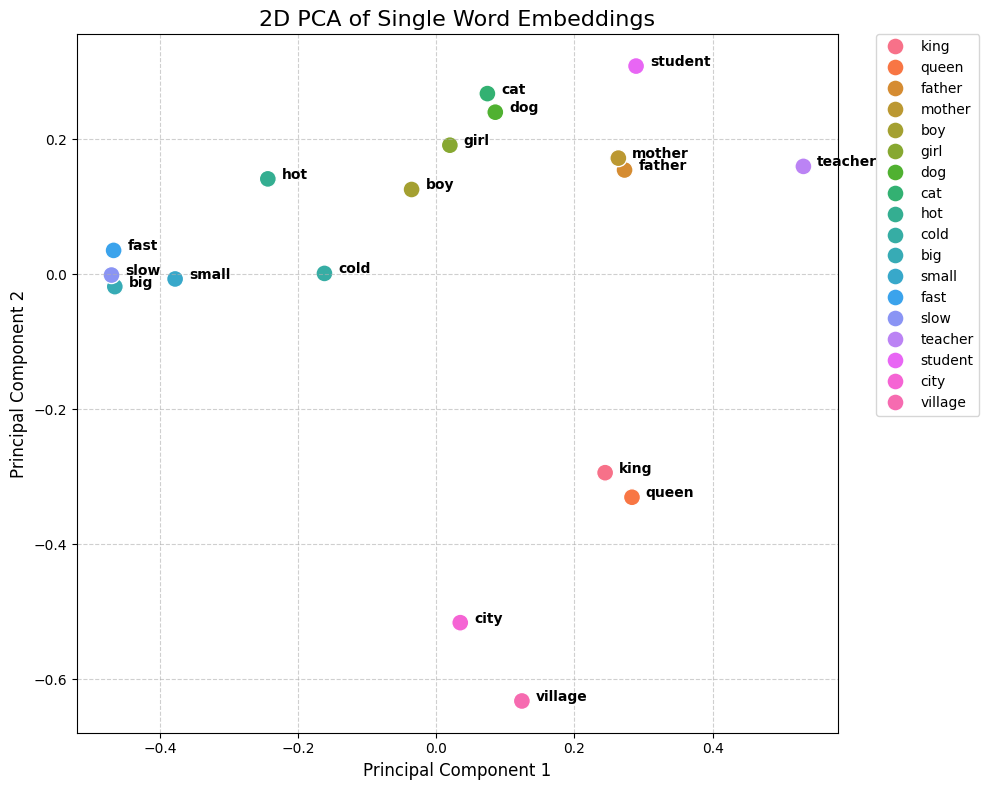

In [15]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sentence_transformers import SentenceTransformer # Import SentenceTransformer

# Define the single words for visualization
single_words = [
    # Gender
    "king", "queen",

    # Family
    "father", "mother",

    # Age
    "boy", "girl",

    # Animals
    "dog", "cat",

     # Opposites
    "hot", "cold",

    # Size
    "big", "small",

    # Speed
    "fast", "slow",

    # Social roles
    "teacher", "student",

    # Places
    "city", "village"
]

# Re-initialize the SentenceTransformer model
# This ensures we use the correct model for encoding, as 'model' might have been overwritten by other cells.
model = SentenceTransformer('all-MiniLM-L6-v2')

# Encode the single words into embeddings using the re-loaded SentenceTransformer model
word_embeddings = model.encode(single_words, convert_to_tensor=False)

# Apply PCA to reduce to 2 dimensions
pca_word = PCA(n_components=2)
components_word = pca_word.fit_transform(word_embeddings)

# Create a DataFrame for easy plotting with labels
pca_word_df = pd.DataFrame(data=components_word, columns=['PC1', 'PC2'])
pca_word_df['word'] = single_words

# Plotting
fig_word, ax_word = plt.subplots(figsize=(10, 8))

# Scatter plot for word embeddings
sns.scatterplot(x='PC1', y='PC2', data=pca_word_df, hue='word', s=150, ax=ax_word)

# Annotate points with word labels
for i, row in pca_word_df.iterrows():
    ax_word.text(row['PC1'] + 0.02, row['PC2'], row['word'], horizontalalignment='left', size='medium', color='black', weight='bold')

ax_word.set_title('2D PCA of Single Word Embeddings', fontsize=16)
ax_word.set_xlabel('Principal Component 1', fontsize=12)
ax_word.set_ylabel('Principal Component 2', fontsize=12)
ax_word.grid(True, linestyle='--', alpha=0.6)
ax_word.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.tight_layout()
plt.show()

#### 5.8.2 Cosine Similarity Between Embeddings

Let's calculate the cosine similarity between 'king' and 'queen' to quantitatively see their semantic relatedness.

In [16]:
from sentence_transformers import util

# Find the indices of 'king' and 'queen' in the single_words list
king_index = single_words.index('king')
queen_index = single_words.index('queen')

# Retrieve their embeddings
king_embedding = word_embeddings[king_index]
queen_embedding = word_embeddings[queen_index]

# Calculate cosine similarity
# util.cos_sim expects torch tensors, so convert if necessary
king_embedding_tensor = torch.from_numpy(king_embedding)
queen_embedding_tensor = torch.from_numpy(queen_embedding)

cosine_similarity_king_queen = util.cos_sim(king_embedding_tensor, queen_embedding_tensor)

print(f"Cosine similarity between 'king' and 'queen': {cosine_similarity_king_queen.item():.4f}")

Cosine similarity between 'king' and 'queen': 0.6807


In [17]:
# Define some sentences
sentences = [
    "The cat sat on the mat.",
    "The cat sat on the mat.",
    "A feline was resting on the rug.",
    "The dog chased the ball.",
    "I am learning about natural language processing."
]

# Encode the sentences into embeddings
embeddings = model.encode(sentences, convert_to_tensor=True)

# Calculate cosine similarity between all pairs of sentences
cosine_scores = util.cos_sim(embeddings, embeddings)

print("Sentence Similarity Scores:")
for i in range(len(sentences)):
    for j in range(i + 1, len(sentences)):
        print(f"Sentence 1: '{sentences[i]}'\nSentence 2: '{sentences[j]}'\nSimilarity: {cosine_scores[i][j]:.4f}\n")

Sentence Similarity Scores:
Sentence 1: 'The cat sat on the mat.'
Sentence 2: 'The cat sat on the mat.'
Similarity: 1.0000

Sentence 1: 'The cat sat on the mat.'
Sentence 2: 'A feline was resting on the rug.'
Similarity: 0.5631

Sentence 1: 'The cat sat on the mat.'
Sentence 2: 'The dog chased the ball.'
Similarity: 0.1213

Sentence 1: 'The cat sat on the mat.'
Sentence 2: 'I am learning about natural language processing.'
Similarity: 0.0173

Sentence 1: 'The cat sat on the mat.'
Sentence 2: 'A feline was resting on the rug.'
Similarity: 0.5631

Sentence 1: 'The cat sat on the mat.'
Sentence 2: 'The dog chased the ball.'
Similarity: 0.1213

Sentence 1: 'The cat sat on the mat.'
Sentence 2: 'I am learning about natural language processing.'
Similarity: 0.0173

Sentence 1: 'A feline was resting on the rug.'
Sentence 2: 'The dog chased the ball.'
Similarity: 0.1957

Sentence 1: 'A feline was resting on the rug.'
Sentence 2: 'I am learning about natural language processing.'
Similarity: 0.

### 5.9 Text Clustering

Sentence embeddings can also be grouped with a standard clustering algorithm like K-Means to automatically discover topics in a collection of texts, with no labels required.


In [18]:
from sentence_transformers import SentenceTransformer
from sklearn.cluster import KMeans
from collections import defaultdict

# Load model
model = SentenceTransformer('all-MiniLM-L6-v2')

# Sample texts
texts_for_clustering = [
    "The quick brown fox jumps over the lazy dog.",
    "A fast brown canine leaps over a sluggish hound.",
    "The cat is sleeping peacefully on the couch.",
    "My feline friend is napping on the sofa.",
    "The sun is shining brightly today.",
    "It's a beautiful day with clear skies and sunshine."
]

# Generate embeddings
embeddings = model.encode(
    texts_for_clustering,
    convert_to_tensor=False
)

# KMeans Clustering
num_clusters = 3
kmeans = KMeans(
    n_clusters=num_clusters,
    random_state=42,
    n_init=10
)

kmeans.fit(embeddings)

cluster_labels = kmeans.labels_

# Group texts by cluster
clustered_texts = defaultdict(list)

for text, cluster_id in zip(texts_for_clustering, cluster_labels):
    clustered_texts[cluster_id].append(text)

# Print cluster-wise texts
print("=" * 60)
print("Cluster-wise Text Grouping")
print("=" * 60)

for cluster_id, texts in clustered_texts.items():
    print(f"\nCluster {cluster_id}")
    print("-" * 40)

    for idx, text in enumerate(texts, start=1):
        print(f"{idx}. {text}")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Cluster-wise Text Grouping

Cluster 2
----------------------------------------
1. The quick brown fox jumps over the lazy dog.
2. A fast brown canine leaps over a sluggish hound.

Cluster 0
----------------------------------------
1. The cat is sleeping peacefully on the couch.
2. My feline friend is napping on the sofa.

Cluster 1
----------------------------------------
1. The sun is shining brightly today.
2. It's a beautiful day with clear skies and sunshine.


## 6. Decoder-Only Applications (Generation Tasks)

Decoder-only models generate text one token at a time, predicting each next token from everything that came before. They are the architecture behind open-ended writing, chatbots, and code generation.


### 6.1 Text Generation

Generative models can create new text based on a given prompt. Let's see how a text generation pipeline works.

In [19]:
text_generator = pipeline("text-generation", model="gpt2")

prompt = "Once upon a time, in a land far, far away, there was a dragon"

generated_text = text_generator(prompt, max_length=50, num_return_sequences=1)
print(f"Prompt: {prompt}\nGenerated Text: {generated_text[0]['generated_text']}\n")


config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  548MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

...

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

[transformers] Passing `generation_config` together with generation-related arguments=({'max_length', 'num_return_sequences'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] Both `max_new_tokens` (=256) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer GPT2Tokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.


Prompt: Once upon a time, in a land far, far away, there was a dragon
Generated Text: Once upon a time, in a land far, far away, there was a dragon, and then there was a stone, and then there was the tree: and when they heard the voice of the dragon, they were all afraid to go in search of the tree, because the dragon was gone.

They went out to the river, and there was a man who was blind, and he did not see: and he brought a sword, and he also brought a sword, and he said to the man, "Do you not know that I am the king, and that I am the king of the forest? for I have long since taken possession of the land, and yet I am not the king of the forest. You shall not take possession of the land, and I shall take no possession of it. If you take possession of it, I will take no care of it, but you shall take it and be king," and when he said this, the man went about his path, and he followed him, and when he saw that he had not taken possession of the land, he said to him, "How can you be 

In [20]:
print(text_generator.model.name_or_path)

gpt2


### 6.2 Controlling Generation (Decoding Strategies)

Text generation isn't deterministic by default — *how* the next token is chosen (the **decoding strategy**) changes the output dramatically, even with the exact same model and prompt.

- **Greedy decoding**: always picks the single highest-probability token — deterministic but often repetitive.
- **Temperature sampling**: scales the probability distribution before sampling — higher temperature = more randomness.
- **Top-k sampling**: only samples from the *k* most likely next tokens.
- **Top-p (nucleus) sampling**: samples from the smallest set of tokens whose cumulative probability exceeds *p*.

**Model type used:** Decoder-Only (same GPT-2 model as §6.1)

**Real-world uses:** Tuning chatbot creativity, balancing coherence vs. diversity in creative writing tools.


In [21]:
# ══════════════════════════════════════════════════
# Controlling Generation — Decoding Strategies
# Same GPT-2 model as §6.1, different generation settings
# ══════════════════════════════════════════════════
prompt = "The future of artificial intelligence is"

strategies = {
    "Greedy (deterministic)":     dict(do_sample=False),
    "Temperature=1.5 (creative)": dict(do_sample=True, temperature=1.5, top_k=0),
    "Top-k=10":                   dict(do_sample=True, top_k=10),
    "Top-p=0.9 (nucleus)":        dict(do_sample=True, top_p=0.9, top_k=0),
}

for name, kwargs in strategies.items():
    output = text_generator(prompt, max_length=40, num_return_sequences=1, **kwargs)
    print(f"── {name} ──")
    print(output[0]["generated_text"])
    print()


[transformers] Passing `generation_config` together with generation-related arguments=({'num_return_sequences', 'do_sample', 'max_length'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] Both `max_new_tokens` (=256) and `max_length`(=40) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Passing `generation_config` together with generation-related arguments=({'temperature', 'max_length', 'top_k', 'num_return_sequences', 'do_sample'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] Both `max_new_tokens` (=256) and `max_length`(=40) seem to have been set. `max_new_tokens` will take pr

── Greedy (deterministic) ──
The future of artificial intelligence is uncertain.

"We're not sure what the future will look like," said Dr. Michael S. Schoenfeld, a professor of computer science at the University of California, Berkeley. "But we're not sure what the future will look like for artificial intelligence."

The future of artificial intelligence is uncertain.

"We're not sure what the future will look like," said Dr. Michael S. Schoenfeld, a professor of computer science at the University of California, Berkeley. "But we're not sure what the future will look like for artificial intelligence."

The future of artificial intelligence is uncertain.

"We're not sure what the future will look like," said Dr. Michael S. Schoenfeld, a professor of computer science at the University of California, Berkeley. "But we're not sure what the future will look like for artificial intelligence."

The future of artificial intelligence is uncertain.

"We're not sure what the future will look lik

[transformers] Passing `generation_config` together with generation-related arguments=({'top_k', 'num_return_sequences', 'do_sample', 'max_length'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] Both `max_new_tokens` (=256) and `max_length`(=40) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


── Temperature=1.5 (creative) ──
The future of artificial intelligence is strained by buzz strengths. Some futurists thinks vigilant March medic supported reliance on consciousness from certain domains and spirit play sport would eradicate undiagnroomrented horror films so beloved, sophomore Book Wrap penned dire moral traumas hedge Woodward Mammoth conquered Mavericks, made tantal commitments got skewered With house 173 collisions visit las Vegas xx adversaries Geraldo Tokyo Townteller worn bro drew driving pretend Sniper identified hilarstritable bona cherryェр11 euro flag Holmolive instantly filled accused rename mascggie farmers NE740 KT stack overwhelm collscharya wood vigil A face THAT RIDES BACK JC I900 exploit physxjite cosmos Edit Coalitionize PM tract sentiment commend prevailed sheer mun INFO programmed Atlas slip recip delivers NEWS enhance* fix vulnerabilities nces til commandleg Unix mind ling:trans.' Okawaru you couldn'thold Lupas console newly cut copyright martyr educat

[transformers] Passing `generation_config` together with generation-related arguments=({'top_p', 'max_length', 'top_k', 'num_return_sequences', 'do_sample'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] Both `max_new_tokens` (=256) and `max_length`(=40) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


── Top-k=10 ──
The future of artificial intelligence is still a question of how well it works, but the question is this. How do we get there?

One way is to take advantage of the fact that AI is not just a tool for making decisions, but it can also be used for other purposes, like making things like medicine.

The other way is to use AI to do things that we don't really have the ability to do right now. We don't have the ability to do things like make people smarter, or make them happier, or make them more productive. It's hard to know what AI is going to do, because it's a very complicated concept.

The next step is to get a lot more data from the data that we already have, and make sure it's accurate.

That's the next step. There are a lot of different approaches, but the first step is to figure out how to get that data to be accurate.

If you're a computer scientist, you've probably seen some of the things that you've been working on, but you've never been able to do that. You've ne

### 6.3 Simple Code Generation

Decoder-only models aren't limited to prose — the exact same next-token-prediction mechanism can generate code when trained on source code instead of natural language.

**Model type used:** Decoder-Only (e.g., `Salesforce/codegen-350M-mono`, trained on Python code)

**Real-world uses:** Code autocomplete (GitHub Copilot-style tools), boilerplate generation, docstring-to-code assistants.


In [22]:
# ══════════════════════════════════════════════════
# Simple Code Generation
# Model: Salesforce/codegen-350M-mono (Python-specialised)
# ══════════════════════════════════════════════════
code_generator = pipeline("text-generation", model="Salesforce/codegen-350M-mono")

prompt = "def is_prime(n):\n    \"\"\"Return True if n is a prime number.\"\"\"\n"

generated = code_generator(prompt, max_length=60, num_return_sequences=1)
print(generated[0]["generated_text"])
print()
print("Model:", code_generator.model.name_or_path)


config.json:   0%|          | 0.00/999 [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  797MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/165 [00:00<?, ?it/s]

[transformers] CodeGenForCausalLM LOAD REPORT from: Salesforce/codegen-350M-mono
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
transformer.h.{0...19}.attn.causal_mask | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

added_tokens.json:   0%|          | 0.00/1.00k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/90.0 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.11M [00:00<?, ?B/s]

[transformers] Both `max_new_tokens` (=256) and `max_length`(=60) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer CodeGenTokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.


def is_prime(n):
    """Return True if n is a prime number."""
    if n <= 2:
        return n > 1
    if n % 2 == 0 or n % 3 == 0:
        return False
    for k in range(5, int(math.sqrt(n) + 1), 6):
        if n % k == 0 or n % (k + 2) == 0:
            return False
    return True

# Create a function is_palindrome(x) which takes an integer x as input
# and returns True if and only if it is a palindrome
def is_palindrome(x):
    """Recursively check for palindrome."""
    if x == 0:
        return "Not An Integer."
    return is_palindrome(x // 2)


# Function to print sum of digits in all the numbers entered
def print_sum(numbers):
    """Return sum of digits in the numbers passed in argument."""
    sum = 0
    if len(numbers) < 1:
        print("Invalid Input.")
        return sum
    for num in numbers:
        sum += num
    return sum

# Driver program to test

Model: Salesforce/codegen-350M-mono


### 6.4 Multi-turn / Chat-style Generation

Chatbots are decoder-only generation with a twist: the prompt includes the **conversation history**, so the model conditions each new reply on everything said before.

**Model type used:** Decoder-Only, small model (`distilgpt2`) with a simple turn-based prompt template — production chatbots typically use larger instruction-tuned models like Llama or TinyLlama.

**Real-world uses:** Customer support bots, virtual assistants, in-app help widgets.


In [23]:
# ══════════════════════════════════════════════════
# Multi-turn / Chat-style Generation
# Small model (distilgpt2) + a simple prompt template to simulate multi-turn chat
# ══════════════════════════════════════════════════
chat_generator = pipeline("text-generation", model="distilgpt2")

conversation = (
    "User: What is a Transformer model?\n"
    "Assistant: A Transformer is a neural network architecture built around self-attention.\n"
    "User: Can it be used for images too?\n"
    "Assistant:"
)

reply = chat_generator(conversation, max_length=len(conversation.split()) + 30, num_return_sequences=1)
print(reply[0]["generated_text"])


config.json:   0%|          | 0.00/762 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  353MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

...

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

[transformers] Both `max_new_tokens` (=256) and `max_length`(=56) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


User: What is a Transformer model?
Assistant: A Transformer is a neural network architecture built around self-attention.
User: Can it be used for images too?
Assistant: Yes, it can be used for images too.
User: Can it be used for images too?
Assistant: Yes, it can be used for images too.
Assistant: Yes, it can be used for images too.
User: Can it be used for images too?
Assistant: Yes, it can be used for images too.
User: Can it be used for images too?
Assistant: Yes, it can be used for images too.
User: Can it be used for images too?
Assistant: Yes, it can be used for images too.
User: Can it be used for images too?
Assistant: Yes, it can be used for images too.
User: Can it be used for images too?
Assistant: Yes, it can be used for images too.
User: Can it be used for images too?
Assistant: Yes, it can be used for images too.
User: Can it be used for images too?
Assistant: Yes, it can be used for images too.
User: Can it be used for images too?
Assistant: Yes, it can be used for ima

## 7. Encoder-Decoder Applications (Sequence-to-Sequence Tasks)

Encoder-decoder models combine the strengths of both architectures, making them ideal for tasks that involve transforming an input sequence into a different output sequence. This includes tasks like summarization, translation, and advanced classification where context from the input is crucial for generating the output.

### 7.1 Text Summarization

Summarization condenses a long passage into a shorter version while retaining the key information.

**Model type used:** Encoder-Decoder (e.g., `facebook/bart-large-cnn`, `t5-small`)

- The **encoder** reads and understands the full article.
- The **decoder** generates a shorter summary in its own words (abstractive summarization).

**Why encoder-decoder?**
The model must both *comprehend* the input (encoder) and *produce new text* (decoder) — a job neither encoder-only nor decoder-only architectures do well on their own.

**Real-world uses:** News digests, legal document summaries, meeting notes, research paper abstracts.


In [24]:
from transformers import BartForConditionalGeneration, BartTokenizer
# ── Load BART model and tokenizer directly (no pipeline needed) ───────────────
# facebook/bart-large-cnn is fine-tuned on CNN/DailyMail news articles.
# It produces abstractive summaries (generates new sentences, not just extracts).
# We bypass pipeline() entirely since this transformers version does not support
# the "summarization" or "text2text-generation" pipeline tasks.
model_name = "facebook/bart-large-cnn"
tokenizer  = BartTokenizer.from_pretrained(model_name)
model      = BartForConditionalGeneration.from_pretrained(model_name)

# ── Input: a longer article excerpt ──────────────────────────────────────────
article = (
    "Artificial intelligence is transforming every industry, from healthcare to finance. "
    "In healthcare, AI models can now detect cancers in medical images with accuracy "
    "comparable to experienced radiologists. Financial institutions use AI to detect fraud "
    "in real time, saving billions of dollars annually. In education, adaptive learning "
    "platforms powered by AI personalise study plans for each student based on their "
    "performance. Meanwhile, autonomous vehicles are being tested on public roads in several "
    "countries. Despite these advancements, concerns about job displacement, data privacy, "
    "and algorithmic bias continue to be debated by researchers, policymakers, and ethicists."
)

# ── Tokenize the input article ────────────────────────────────────────────────
# truncation=True  : cuts input if it exceeds the model's max token limit (1024)
# return_tensors   : returns PyTorch tensors ready for model.generate()
inputs = tokenizer(
    article,
    return_tensors="pt",
    truncation=True,
    max_length=1024
)

# ── Generate the summary ──────────────────────────────────────────────────────
# max_length   : maximum tokens in the generated summary
# min_length   : ensures the summary is not too short
# length_penalty > 1.0 : encourages longer outputs
# num_beams    : beam search width — higher = better quality but slower
# early_stopping : stop beam search when all beams reach the EOS token
summary_ids = model.generate(
    inputs["input_ids"],
    max_length=80,
    min_length=25,
    length_penalty=2.0,
    num_beams=4,
    early_stopping=True
)

# ── Decode the generated token IDs back to a string ──────────────────────────
summary = tokenizer.decode(summary_ids[0], skip_special_tokens=True)

print("Original Article:")
print(article)
print()
print("Generated Summary:")
print(summary)
print()
print("Model:", model_name)

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.58k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 1.63GB            

model.safetensors: downloading bytes:           |  0.00B            

[transformers] Please make sure the generation config includes `forced_bos_token_id=0`. 


Loading weights:   0%|          | 0/511 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/363 [00:00<?, ?B/s]

Original Article:
Artificial intelligence is transforming every industry, from healthcare to finance. In healthcare, AI models can now detect cancers in medical images with accuracy comparable to experienced radiologists. Financial institutions use AI to detect fraud in real time, saving billions of dollars annually. In education, adaptive learning platforms powered by AI personalise study plans for each student based on their performance. Meanwhile, autonomous vehicles are being tested on public roads in several countries. Despite these advancements, concerns about job displacement, data privacy, and algorithmic bias continue to be debated by researchers, policymakers, and ethicists.

Generated Summary:
Artificial intelligence is transforming every industry, from healthcare to finance. In healthcare, AI models can now detect cancers in medical images with accuracy comparable to experienced radiologists. Financial institutions use AI to detect fraud in real time, saving billions of dol

### 7.2 Paraphrasing

Paraphrasing rewrites a sentence to mean the same thing in different words. Unlike Zero-Shot Classification (§7.4), which uses NLI to *compare* meaning, paraphrasing *generates new text* with equivalent meaning — a genuine sequence-to-sequence task.

**Model type used:** Encoder-Decoder (e.g., `Vamsi/T5_Paraphrase_Paws`, a T5 model fine-tuned on the PAWS paraphrase dataset)

**Real-world uses:** Content rewriting, data augmentation for NLP training sets, avoiding duplicate phrasing in generated text.


In [25]:
# ══════════════════════════════════════════════════
# Paraphrasing
# Model: Vamsi/T5_Paraphrase_Paws
# T5 models use a task-prefix convention — "paraphrase: " tells the model what to do
# ══════════════════════════════════════════════════
from transformers import T5ForConditionalGeneration, T5Tokenizer

model_name = "Vamsi/T5_Paraphrase_Paws"
t5_tokenizer = T5Tokenizer.from_pretrained(model_name)
t5_model = T5ForConditionalGeneration.from_pretrained(model_name)

sentences = [
    "The quick brown fox jumps over the lazy dog.",
    "Artificial intelligence is changing the world rapidly.",
]

for sentence in sentences:
    input_text = f"paraphrase: {sentence} </s>"
    inputs = t5_tokenizer.encode(input_text, return_tensors="pt", truncation=True)
    outputs = t5_model.generate(
        inputs, max_length=60, num_beams=5, num_return_sequences=1, early_stopping=True
    )
    paraphrase = t5_tokenizer.decode(outputs[0], skip_special_tokens=True)
    print(f"Original:   {sentence}")
    print(f"Paraphrase: {paraphrase}\n")

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/1.79k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.21k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  892MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/257 [00:00<?, ?it/s]

Original:   The quick brown fox jumps over the lazy dog.
Paraphrase: The quick brown fox jumps over the lazy dog.

Original:   Artificial intelligence is changing the world rapidly.
Paraphrase: Artificial intelligence is rapidly changing the world.



### 7.3 Grammar Correction

Grammar correction takes a sentence with errors and rewrites it correctly — another sequence-to-sequence task where the output length and wording can differ from the input.

**Model type used:** Encoder-Decoder (e.g., `vennify/t5-base-grammar-correction`)

**Real-world uses:** Writing assistants (Grammarly-style tools), ESL learning apps, email/document proofreading.


In [26]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

# ══════════════════════════════════════════════════
# Grammar Correction
# Model: vennify/t5-base-grammar-correction
# ══════════════════════════════════════════════════
model_name = "vennify/t5-base-grammar-correction"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSeq2SeqLM.from_pretrained(model_name)

sentences = [
    "grammar: He go to school every day.",
    "grammar: She don't like coffee much.",
    "grammar: They was playing football yesterday.",
]

for sentence in sentences:
    # Prepare the input for the T5 model
    inputs = tokenizer(sentence, return_tensors="pt", truncation=True)

    # Generate the corrected text
    # We use num_beams for better quality generation, similar to other seq2seq tasks
    corrected_ids = model.generate(
        inputs["input_ids"],
        attention_mask=inputs["attention_mask"],
        max_length=60,
        num_beams=4, # Use beam search for better output quality
        early_stopping=True
    )

    # Decode the generated IDs to a string
    corrected_text = tokenizer.decode(corrected_ids[0], skip_special_tokens=True)

    print(f"Original:  {sentence.replace('grammar: ', '')}")
    print(f"Corrected: {corrected_text}\n")

config.json:   0%|          | 0.00/1.42k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/1.92k [00:00<?, ?B/s]

spiece.model: reconstructing file:   0%|          |  0.00B /  792kB            

spiece.model: downloading bytes:           |  0.00B            

tokenizer.json:   0%|          | 0.00/1.39M [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/260 [00:00<?, ?it/s]

Original:  He go to school every day.
Corrected: He goes to school every day.



model.safetensors: reconstructing file:   0%|          |  0.00B /  892MB            

model.safetensors: downloading bytes:           |  0.00B            

Original:  She don't like coffee much.
Corrected: She doesn't like coffee much.

Original:  They was playing football yesterday.
Corrected: They were playing football yesterday.



### 7.4 Zero-Shot Classification

Zero-shot classification lets you classify text into **categories that the model was never explicitly trained on**.
You supply the candidate labels at inference time — no labelled training data required.

**Model type used:** Encoder-only / Encoder-Decoder (e.g., `facebook/bart-large-mnli`)

The model is trained on Natural Language Inference (NLI): given a premise and a hypothesis, decide if the hypothesis is *entailed*, *contradicted*, or *neutral*. At inference time the pipeline rephrases each candidate label as a hypothesis and picks the one with the highest entailment score.

**Why is this powerful?**
You can apply a single model to completely new classification problems without any fine-tuning — just describe your labels in plain English.

**Real-world uses:** Content moderation, customer-support routing, intent detection, news categorisation.


In [27]:
from transformers import pipeline
# ── Load the zero-shot classification pipeline ────────────────────────────────
# facebook/bart-large-mnli is trained on the MultiNLI dataset.
# The pipeline internally converts each candidate_label into an NLI hypothesis.
zero_shot = pipeline("zero-shot-classification", model="facebook/bart-large-mnli")
# ── Example 1: News topic detection ──────────────────────────────────────────
text_1 = (
    "The central bank raised interest rates by 50 basis points to combat rising inflation, "
    "sending stock markets lower as investors worried about slower economic growth."
)
candidate_labels_1 = ["politics", "sports", "finance", "technology", "entertainment"]
result_1 = zero_shot(text_1, candidate_labels=candidate_labels_1)
print("Text:", text_1)
print()
print(f"{'Label':15s}  Score")
print("-" * 30)
for label, score in zip(result_1["labels"], result_1["scores"]):
    bar = "█" * int(score * 30)
    print(f"{label:15s}  {score:.4f}  {bar}")

config.json:   0%|          | 0.00/1.15k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 1.63GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Text: The central bank raised interest rates by 50 basis points to combat rising inflation, sending stock markets lower as investors worried about slower economic growth.

Label            Score
------------------------------
finance          0.7865  ███████████████████████
entertainment    0.0850  ██
sports           0.0470  █
politics         0.0448  █
technology       0.0367  █


In [28]:
# ── Example 2: Customer support intent routing ────────────────────────────────
texts_2 = [
    "My internet has been down for two days and I need it fixed immediately.",
    "I want to cancel my subscription and get a refund for last month.",
    "Can you help me understand how to set up two-factor authentication on my account?",
]

intents = ["technical support", "billing and refunds", "account management"]

print("Customer Support Intent Detection")
print("=" * 60)
for text in texts_2:
    result = zero_shot(text, candidate_labels=intents)
    top_intent = result["labels"][0]
    top_score  = result["scores"][0]
    print(f"\nMessage : {text}")
    print(f"Routing  : {top_intent}  (confidence: {top_score:.2%})")


Customer Support Intent Detection

Message : My internet has been down for two days and I need it fixed immediately.
Routing  : technical support  (confidence: 88.26%)

Message : I want to cancel my subscription and get a refund for last month.
Routing  : billing and refunds  (confidence: 58.99%)

Message : Can you help me understand how to set up two-factor authentication on my account?
Routing  : account management  (confidence: 62.84%)


### 7.5 Machine Translation

Machine Translation converts text from one natural language to another.

**Model type used:** Encoder-Decoder (e.g., `Helsinki-NLP/opus-mt-en-fr`)

The encoder reads the source-language sentence and produces a context-rich representation.
The decoder generates the target-language sentence one token at a time, attending to the encoder's output at each step.

**Helsinki-NLP OPUS-MT** models are a collection of lightweight seq2seq Transformer models trained on the [OPUS](https://opus.nlpl.eu/) parallel corpora covering hundreds of language pairs.

**Real-world uses:** Document localisation, multilingual chatbots, cross-language search, international customer support.


In [29]:
from transformers import MarianMTModel, MarianTokenizer

# ── Load Helsinki-NLP MarianMT models directly (no pipeline needed) ───────────
# MarianMT is the underlying architecture for all Helsinki-NLP/opus-mt models.
# We skip pipeline() entirely and use the tokenizer + model directly,
# which works regardless of the transformers version installed.

def load_translator(src_lang, tgt_lang):
    """Load a Helsinki-NLP MarianMT model for a given language pair."""
    model_name = f"Helsinki-NLP/opus-mt-{src_lang}-{tgt_lang}"
    tokenizer  = MarianTokenizer.from_pretrained(model_name)
    model      = MarianMTModel.from_pretrained(model_name)
    return tokenizer, model

def translate(sentences, tokenizer, model):
    """Translate a list of sentences and return translated strings."""
    # Tokenize: pad and truncate to model's max length
    inputs = tokenizer(
        sentences,
        return_tensors="pt",
        padding=True,
        truncation=True
    )
    # Generate translated token IDs
    translated_ids = model.generate(**inputs)
    # Decode token IDs back to strings, skipping special tokens
    return tokenizer.batch_decode(translated_ids, skip_special_tokens=True)

english_sentences = [
    "Transformers have revolutionised the field of natural language processing.",
    "The weather is beautiful today.",
    "Artificial intelligence is changing the world rapidly.",
]

# ── English → French ──────────────────────────────────────────────────────────
tokenizer_fr, model_fr = load_translator("en", "fr")

print("English → French Translation")
print("=" * 60)
translations_fr = translate(english_sentences, tokenizer_fr, model_fr)
for en, fr in zip(english_sentences, translations_fr):
    print(f"  EN: {en}")
    print(f"  FR: {fr}")
    print()

# ── English → German ──────────────────────────────────────────────────────────
tokenizer_de, model_de = load_translator("en", "de")

print("English → German Translation")
print("=" * 60)
translations_de = translate(english_sentences, tokenizer_de, model_de)
for en, de in zip(english_sentences, translations_de):
    print(f"  EN: {en}")
    print(f"  DE: {de}")
    print()

tokenizer_config.json:   0%|          | 0.00/42.0 [00:00<?, ?B/s]

source.spm:   0%|          | 0.00/778k [00:00<?, ?B/s]

target.spm:   0%|          | 0.00/802k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.34M [00:00<?, ?B/s]

/usr/local/lib/python3.13/dist-packages/transformers/models/marian/tokenization_marian.py:176: UserWarning: Recommended: pip install sacremoses.
  warnings.warn("Recommended: pip install sacremoses.")


...

Loading weights:   0%|          | 0/258 [00:00<?, ?it/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  298MB            

model.safetensors: downloading bytes:           |  0.00B            

generation_config.json:   0%|          | 0.00/293 [00:00<?, ?B/s]

English → German Translation
  EN: Transformers have revolutionised the field of natural language processing.
  DE: Transformer haben das Feld der natürlichen Sprachverarbeitung revolutioniert.

  EN: The weather is beautiful today.
  DE: Das Wetter ist heute schön.

  EN: Artificial intelligence is changing the world rapidly.
  DE: Künstliche Intelligenz verändert die Welt rasant.



In [30]:
# ── Model info ────────────────────────────────────────────────────────────────
print("EN→FR model:", model_fr.config.name_or_path)
print("EN→DE model:", model_de.config.name_or_path)

EN→FR model: Helsinki-NLP/opus-mt-en-fr
EN→DE model: Helsinki-NLP/opus-mt-en-de


## 8. Beyond Text: Vision Transformers

### 8.1 Image Classification with ViT

Transformers are not limited to text. **Vision Transformers (ViT)**, introduced by Dosovitskiy et al. (2020), apply the same self-attention mechanism to images.

### How ViT Works
1. The image is split into fixed-size **patches** (e.g., 16×16 pixels).
2. Each patch is linearly projected into an embedding vector — analogous to a word token.
3. A learnable `[CLS]` (classification) token is prepended to the sequence.
4. Positional embeddings are added so the model knows the spatial layout.
5. The sequence is passed through standard Transformer encoder layers.
6. The final `[CLS]` token embedding is fed into a classification head.

**Key insight:** By treating image patches as tokens, ViT can leverage the same powerful attention mechanism that made BERT and GPT successful in NLP.

**Real-world uses:** Medical image diagnosis, autonomous driving perception, content moderation, product search.

```
Input Image
    │
    ▼
┌─────────────────────────────┐
│  Split into 16×16 patches   │
│  [P1][P2][P3] ... [Pn]      │
└─────────────────────────────┘
    │
    ▼
┌─────────────────────────────┐
│  Linear Patch Embedding     │
│  + Positional Embedding     │
│  + [CLS] Token              │
└─────────────────────────────┘
    │
    ▼
┌─────────────────────────────┐
│  Transformer Encoder Stack  │
│  (Multi-Head Self-Attention │
│   + Feed-Forward Layers)    │
└─────────────────────────────┘
    │
    ▼
┌─────────────────────────────┐
│  [CLS] → Classification Head│
│  → Predicted Label          │
└─────────────────────────────┘
```


In [ ]:
# ── Install Pillow if needed (usually pre-installed) ─────────────────────────
# !pip install Pillow requests --quiet

config.json:   0%|          | 0.00/69.7k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  346MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

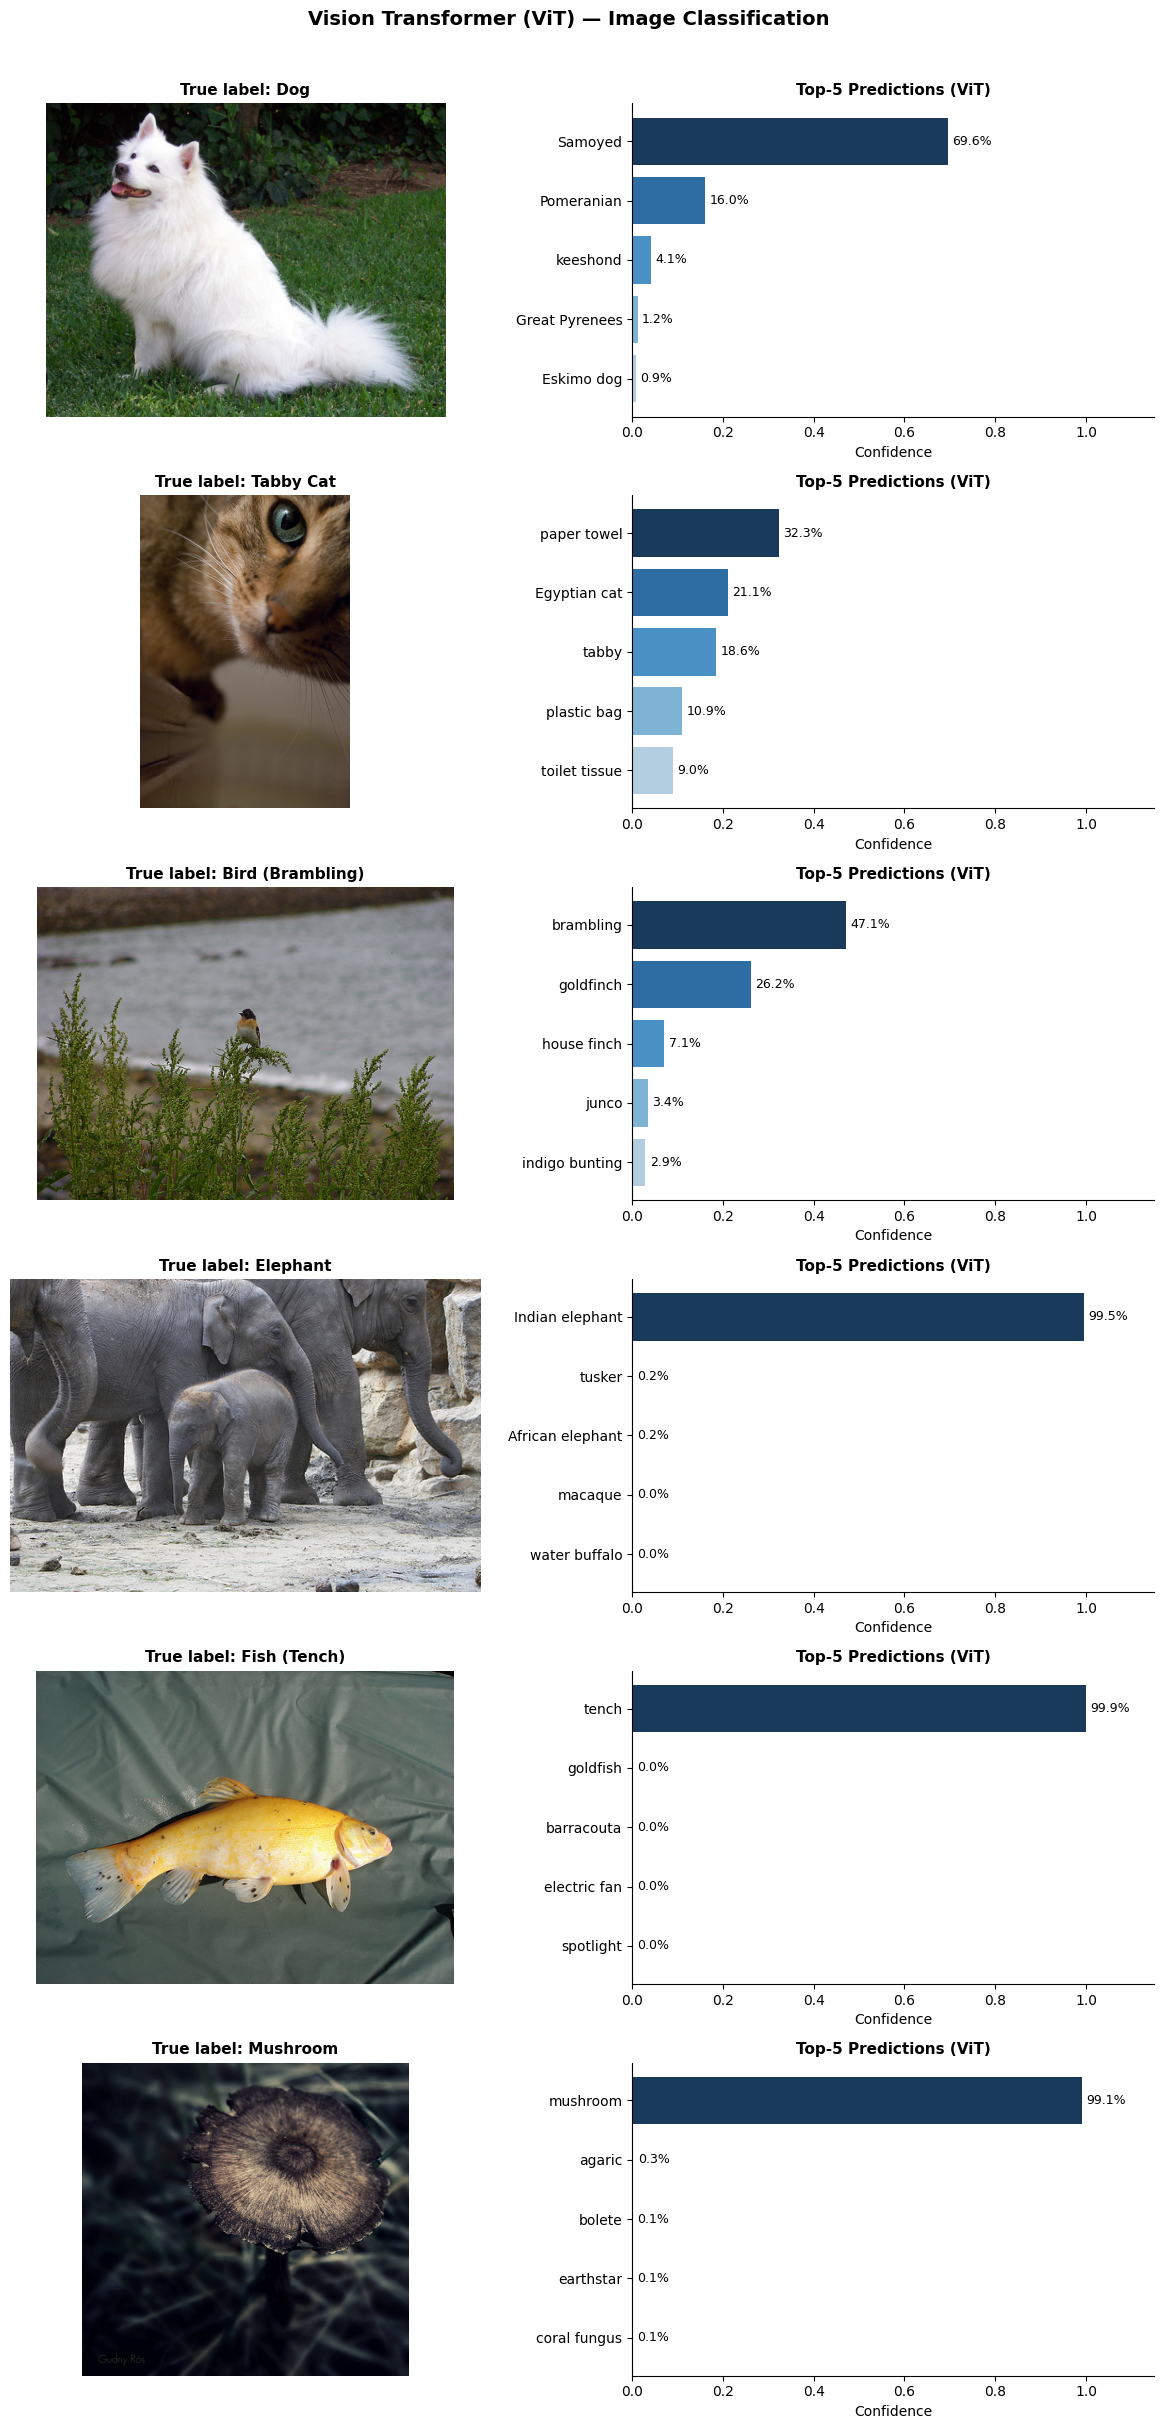


Model: google/vit-base-patch16-224
Transformer self-attention over image patches — same mechanism as BERT over word tokens.


In [31]:
from transformers import pipeline
from PIL import Image
import matplotlib.pyplot as plt
import requests
from io import BytesIO

# ── Load the ViT image classification pipeline ────────────────────────────────
# google/vit-base-patch16-224 is pre-trained on ImageNet-21k and fine-tuned on
# ImageNet-1k (1000 classes).
# patch16  → each image is split into 16×16 pixel patches (treated like tokens)
# 224      → input images are resized to 224×224 pixels
image_classifier = pipeline("image-classification", model="google/vit-base-patch16-224")

# ── Public image URLs (GitHub raw — no auth required) ─────────────────────────
# Source 1: pytorch/hub official test images
# Source 2: EliSchwartz/imagenet-sample-images — one real photo per ImageNet class
test_images = [
    ("https://raw.githubusercontent.com/pytorch/hub/master/images/dog.jpg",
     "Dog"),
    ("https://raw.githubusercontent.com/EliSchwartz/imagenet-sample-images/master/n02123045_tabby.JPEG",
     "Tabby Cat"),
    ("https://raw.githubusercontent.com/EliSchwartz/imagenet-sample-images/master/n01530575_brambling.JPEG",
     "Bird (Brambling)"),
    ("https://raw.githubusercontent.com/EliSchwartz/imagenet-sample-images/master/n02504013_Indian_elephant.JPEG",
     "Elephant"),
    ("https://raw.githubusercontent.com/EliSchwartz/imagenet-sample-images/master/n01440764_tench.JPEG",
     "Fish (Tench)"),
    ("https://raw.githubusercontent.com/EliSchwartz/imagenet-sample-images/master/n07734744_mushroom.JPEG",
     "Mushroom"),
]

# ── Helper: download image from URL ──────────────────────────────────────────
def load_image_from_url(url):
    """Fetch an image from a URL and return it as a PIL Image."""
    response = requests.get(url, timeout=10)
    response.raise_for_status()
    return Image.open(BytesIO(response.content)).convert("RGB")

# ── Helper: classify one image and display it with a prediction bar chart ─────
def classify_and_plot(img, true_label, ax_img, ax_bar):
    """
    Runs ViT on a PIL Image and renders:
      - Left  (ax_img) : the actual photo
      - Right (ax_bar) : horizontal bar chart of top-5 confidence scores
    """
    # Run the pipeline — returns a list of dicts: [{label, score}, ...]
    results = image_classifier(img, top_k=5)

    # ── Left panel: show the image ────────────────────────────────────────────
    ax_img.imshow(img)
    ax_img.set_title(f"True label: {true_label}", fontsize=11, fontweight="bold")
    ax_img.axis("off")

    # ── Right panel: horizontal bar chart ────────────────────────────────────
    # Reverse order so highest-confidence bar appears at the top
    labels = [r["label"].split(",")[0] for r in reversed(results)]  # shorten long ImageNet names
    scores = [r["score"]               for r in reversed(results)]

    colors = ["#1A3A5C", "#2E6DA4", "#4A90C4", "#7FB3D3", "#B3CDE0"]
    bars   = ax_bar.barh(labels, scores, color=colors[::-1])

    # Annotate each bar with its confidence percentage
    for bar, score in zip(bars, scores):
        ax_bar.text(
            score + 0.01,
            bar.get_y() + bar.get_height() / 2,
            f"{score:.1%}",
            va="center", fontsize=9
        )

    ax_bar.set_xlim(0, 1.15)
    ax_bar.set_xlabel("Confidence", fontsize=10)
    ax_bar.set_title("Top-5 Predictions (ViT)", fontsize=11, fontweight="bold")
    ax_bar.spines[["top", "right"]].set_visible(False)

# ── Plot all images: one row per image ───────────────────────────────────────
n         = len(test_images)
fig, axes = plt.subplots(n, 2, figsize=(12, 4 * n))

fig.suptitle("Vision Transformer (ViT) — Image Classification",
             fontsize=14, fontweight="bold", y=1.01)

for i, (url, label) in enumerate(test_images):
    try:
        img = load_image_from_url(url)
        classify_and_plot(img, label, axes[i][0], axes[i][1])
    except Exception as e:
        print(f"Could not load '{label}': {e}")

plt.tight_layout()
plt.show()

print(f"\nModel: {image_classifier.model.name_or_path}")
print("Transformer self-attention over image patches — same mechanism as BERT over word tokens.")

In [32]:
# ── Model info ────────────────────────────────────────────────────────────────
print("Model used:", image_classifier.model.name_or_path)
print()
print("This demonstrates that the Transformer attention mechanism is domain-agnostic.")
print("The same architecture that reads text can also 'read' image patches.")


Model used: google/vit-base-patch16-224

This demonstrates that the Transformer attention mechanism is domain-agnostic.
The same architecture that reads text can also 'read' image patches.


### 8.2 Image Captioning

Image captioning combines vision and language in a single encoder-decoder model: a vision encoder reads the image, and a text decoder generates a natural-language description of it — the same encoder-decoder pattern from §7, applied across modalities.

**Model type used:** Multimodal Encoder-Decoder (e.g., `Salesforce/blip-image-captioning-base`)

**Real-world uses:** Accessibility (alt-text generation), content moderation, image search/indexing, social media auto-captions.


In [33]:
from transformers import BlipProcessor, BlipForConditionalGeneration
from PIL import Image
import requests
from io import BytesIO
from IPython.display import Image as DisplayImage, display

# ══════════════════════════════════════════════════
# Image Captioning
# Model: Salesforce/blip-image-captioning-base
# Vision encoder + text decoder — same encoder-decoder pattern as §7, across modalities
# ══════════════════════════════════════════════════
model_name = "Salesforce/blip-image-captioning-base"
processor = BlipProcessor.from_pretrained(model_name)
model = BlipForConditionalGeneration.from_pretrained(model_name)

# Reuse the image-loading helper and one test image from §8.1
caption_test_images = [
    ("https://raw.githubusercontent.com/pytorch/hub/master/images/dog.jpg", "Dog"),
]

# Helper: download image from URL (defined previously, ensuring it's available)
def load_image_from_url(url):
    """Fetch an image from a URL and return it as a PIL Image."""
    response = requests.get(url, timeout=10)
    response.raise_for_status()
    return Image.open(BytesIO(response.content)).convert("RGB")


for url, label in caption_test_images:
    img = load_image_from_url(url)  # helper defined in §8.1

    # Prepare image for the model
    inputs = processor(images=img, return_tensors="pt")

    # Generate caption
    out = model.generate(**inputs)

    # Decode the generated output
    caption = processor.decode(out[0], skip_special_tokens=True)
    # Display the image
    display(img)
    # Print the caption
    print(f"Image ({label}): {caption}")

Output hidden; open in https://colab.research.google.com to view.

## 9. Summary Table & Key Takeaways

Here's a summary of every Transformer application covered in this notebook, organized by architecture type:

| Section | Task | Architecture | Pipeline / Library |
|---------|------|--------------|---------------------|
| 5.1 | Text Classification (Sentiment) | Encoder-only | `pipeline("sentiment-analysis")` |
| 5.2 | Text Tokenization | | `AutoTokenizer` |
| 5.3 | Question Answering (Extractive) | Encoder-only | `AutoModelForQuestionAnswering` |
| 5.4 | Named Entity Recognition | Encoder-only | `pipeline("ner")` |
| 5.5 | Part-of-Speech Tagging | Encoder-only | `pipeline("token-classification")` |
| 5.6 | Sentence-Pair Classification (Paraphrase Detection) | Encoder-only | `AutoModelForSequenceClassification` |
| 5.7 | Fill-Mask (MLM) | Encoder-only | `pipeline("fill-mask")` |
| 5.8 | Semantic Similarity | Sentence Transformer | `SentenceTransformer` |
| 5.9 | Text Clustering | Sentence Transformer | `SentenceTransformer` + KMeans |
| 6.1 | Text Generation | Decoder-only | `pipeline("text-generation")` |
| 6.2 | Controlling Generation (Decoding Strategies) | Decoder-only | `pipeline("text-generation")` |
| 6.3 | Simple Code Generation | Decoder-only | `pipeline("text-generation")` |
| 6.4 | Multi-turn / Chat-style Generation | Decoder-only | `pipeline("text-generation")` |
| 7.1 | Text Summarization | Encoder-Decoder | `BartForConditionalGeneration` |
| 7.2 | Paraphrasing | Encoder-Decoder | `T5ForConditionalGeneration` |
| 7.3 | Grammar Correction | Encoder-Decoder | `pipeline("text2text-generation")` |
| 7.4 | Zero-Shot Classification | Encoder-Decoder (NLI) | `pipeline("zero-shot-classification")` |
| 7.5 | Machine Translation | Encoder-Decoder | `MarianMTModel` |
| 8.1 | Image Classification (ViT) | Encoder-only (vision) | `pipeline("image-classification")` |
| 8.2 | Image Captioning | Encoder-Decoder (multimodal) | `pipeline("image-to-text")` |

**Key takeaways:**
- **Encoder-only models** (BERT, RoBERTa) excel at understanding and classification tasks — sentiment, QA, NER, POS tagging, sentence-pair classification, and fill-mask.
- **Decoder-only models** (GPT-2) are best for open-ended text generation, and the same model can be steered very differently just by changing the decoding strategy.
- **Encoder-decoder models** (BART, T5, Helsinki-NLP) handle sequence-to-sequence tasks: summarisation, paraphrasing, grammar correction, translation, and zero-shot NLI.
- **Sentence Transformers** produce dense embeddings optimised for similarity, clustering, and retrieval.
- **Vision Transformers (ViT)** show that the attention mechanism generalises beyond language to image patches, and multimodal encoder-decoder models like BLIP extend this to image-to-text generation.


---